In [3]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from langgraph.checkpoint.memory import InMemorySaver
from langchain_openai.chat_models.azure import AzureChatOpenAI
from dotenv import load_dotenv
load_dotenv(dotenv_path="C:\Agentic AI\.env", override=True)

True

In [4]:
llm = AzureChatOpenAI(azure_deployment="gpt-4o")

In [5]:
class JokeState(TypedDict):

    topic: str
    joke: str
    explanation: str

In [6]:
def generate_joke(state: JokeState):

    prompt = f'generate a joke on the topic {state["topic"]}'
    response = llm.invoke(prompt).content

    return {'joke': response}

In [7]:
def generate_explanation(state: JokeState):

    prompt = f'write an explanation for the joke - {state["joke"]}'
    response = llm.invoke(prompt).content

    return {'explanation': response}

In [8]:
graph = StateGraph(JokeState)

graph.add_node('generate_joke', generate_joke)
graph.add_node('generate_explanation', generate_explanation)

graph.add_edge(START, 'generate_joke')
graph.add_edge('generate_joke', 'generate_explanation')
graph.add_edge('generate_explanation', END)

checkpointer = InMemorySaver()

workflow = graph.compile(checkpointer=checkpointer)

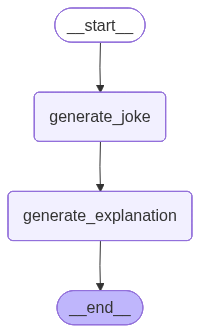

In [9]:
workflow

In [10]:
config1 = {"configurable": {"thread_id": "1"}}
workflow.invoke({'topic':'pizza'}, config=config1)

{'topic': 'pizza',
 'joke': "Sure! Here's a pizza joke for you:\n\nWhat’s a pizza maker’s favorite type of music?\n\n**Cheesy pop!** 🍕🎶",
 'explanation': 'The humor in this joke comes from the clever wordplay and the double meaning of the phrase "cheesy pop." Here\'s the breakdown:\n\n- **Cheesy pop** refers to a genre of music, typically pop songs that are fun, lighthearted, and sometimes considered overly sweet or cliché—hence "cheesy."\n- At the same time, pizza makers often work with cheese as a key ingredient, so "cheesy" ties directly to their craft.\n- The joke connects these two meanings in a playful way, making it amusing because of the unexpected and punny connection between pizza and music.\n\nIt’s a classic "dad joke" style pun—simple, light, and sure to earn a chuckle (or maybe a groan)!'}

In [11]:
workflow.get_state(config1)

StateSnapshot(values={'topic': 'pizza', 'joke': "Sure! Here's a pizza joke for you:\n\nWhat’s a pizza maker’s favorite type of music?\n\n**Cheesy pop!** 🍕🎶", 'explanation': 'The humor in this joke comes from the clever wordplay and the double meaning of the phrase "cheesy pop." Here\'s the breakdown:\n\n- **Cheesy pop** refers to a genre of music, typically pop songs that are fun, lighthearted, and sometimes considered overly sweet or cliché—hence "cheesy."\n- At the same time, pizza makers often work with cheese as a key ingredient, so "cheesy" ties directly to their craft.\n- The joke connects these two meanings in a playful way, making it amusing because of the unexpected and punny connection between pizza and music.\n\nIt’s a classic "dad joke" style pun—simple, light, and sure to earn a chuckle (or maybe a groan)!'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f0b3a1f-f923-66a6-8002-aeef8500934e'}}, metadata={'source': 'loop', 'step'

In [12]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': "Sure! Here's a pizza joke for you:\n\nWhat’s a pizza maker’s favorite type of music?\n\n**Cheesy pop!** 🍕🎶", 'explanation': 'The humor in this joke comes from the clever wordplay and the double meaning of the phrase "cheesy pop." Here\'s the breakdown:\n\n- **Cheesy pop** refers to a genre of music, typically pop songs that are fun, lighthearted, and sometimes considered overly sweet or cliché—hence "cheesy."\n- At the same time, pizza makers often work with cheese as a key ingredient, so "cheesy" ties directly to their craft.\n- The joke connects these two meanings in a playful way, making it amusing because of the unexpected and punny connection between pizza and music.\n\nIt’s a classic "dad joke" style pun—simple, light, and sure to earn a chuckle (or maybe a groan)!'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f0b3a1f-f923-66a6-8002-aeef8500934e'}}, metadata={'source': 'loop', 'step

In [13]:
config2 = {"configurable": {"thread_id": "2"}}
workflow.invoke({'topic':'pasta'}, config=config2)

{'topic': 'pasta',
 'joke': 'Why did the pasta break up with the bread?\n\nBecause it found him too *kneady*! 🍝',
 'explanation': 'Certainly! Here\'s an explanation of the joke:\n\nThe humor in this joke comes from a pun on the word *kneady*, which sounds like "needy." In this context:\n\n- Bread is made by kneading dough, so "kneady" is a play on the process of preparing bread.\n- At the same time, "needy" is a term often used to describe someone who is overly dependent or emotionally clingy in a relationship.\n\nThe pasta broke up with the bread because it found the bread "too kneady"—a clever wordplay suggesting that the bread was both literally associated with kneading (as a food) and metaphorically "too needy" (as a partner)!\n\nThe emoji 🍝 adds charm by reinforcing the pasta theme of the joke.'}

In [14]:
workflow.get_state(config1)

StateSnapshot(values={'topic': 'pizza', 'joke': "Sure! Here's a pizza joke for you:\n\nWhat’s a pizza maker’s favorite type of music?\n\n**Cheesy pop!** 🍕🎶", 'explanation': 'The humor in this joke comes from the clever wordplay and the double meaning of the phrase "cheesy pop." Here\'s the breakdown:\n\n- **Cheesy pop** refers to a genre of music, typically pop songs that are fun, lighthearted, and sometimes considered overly sweet or cliché—hence "cheesy."\n- At the same time, pizza makers often work with cheese as a key ingredient, so "cheesy" ties directly to their craft.\n- The joke connects these two meanings in a playful way, making it amusing because of the unexpected and punny connection between pizza and music.\n\nIt’s a classic "dad joke" style pun—simple, light, and sure to earn a chuckle (or maybe a groan)!'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f0b3a1f-f923-66a6-8002-aeef8500934e'}}, metadata={'source': 'loop', 'step'

In [15]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': "Sure! Here's a pizza joke for you:\n\nWhat’s a pizza maker’s favorite type of music?\n\n**Cheesy pop!** 🍕🎶", 'explanation': 'The humor in this joke comes from the clever wordplay and the double meaning of the phrase "cheesy pop." Here\'s the breakdown:\n\n- **Cheesy pop** refers to a genre of music, typically pop songs that are fun, lighthearted, and sometimes considered overly sweet or cliché—hence "cheesy."\n- At the same time, pizza makers often work with cheese as a key ingredient, so "cheesy" ties directly to their craft.\n- The joke connects these two meanings in a playful way, making it amusing because of the unexpected and punny connection between pizza and music.\n\nIt’s a classic "dad joke" style pun—simple, light, and sure to earn a chuckle (or maybe a groan)!'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f0b3a1f-f923-66a6-8002-aeef8500934e'}}, metadata={'source': 'loop', 'step

### Time Travel

In [16]:
workflow.get_state({"configurable": {"thread_id": "1", "checkpoint_id": "1f06cc6e-7232-6cb1-8000-f71609e6cec5"}})

StateSnapshot(values={}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_id': '1f06cc6e-7232-6cb1-8000-f71609e6cec5'}}, metadata=None, created_at=None, parent_config=None, tasks=(), interrupts=())

In [17]:
workflow.invoke(None, {"configurable": {"thread_id": "1", "checkpoint_id": "1f06cc6e-7232-6cb1-8000-f71609e6cec5"}})

EmptyInputError: Received no input for __start__

In [18]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': "Sure! Here's a pizza joke for you:\n\nWhat’s a pizza maker’s favorite type of music?\n\n**Cheesy pop!** 🍕🎶", 'explanation': 'The humor in this joke comes from the clever wordplay and the double meaning of the phrase "cheesy pop." Here\'s the breakdown:\n\n- **Cheesy pop** refers to a genre of music, typically pop songs that are fun, lighthearted, and sometimes considered overly sweet or cliché—hence "cheesy."\n- At the same time, pizza makers often work with cheese as a key ingredient, so "cheesy" ties directly to their craft.\n- The joke connects these two meanings in a playful way, making it amusing because of the unexpected and punny connection between pizza and music.\n\nIt’s a classic "dad joke" style pun—simple, light, and sure to earn a chuckle (or maybe a groan)!'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f0b3a1f-f923-66a6-8002-aeef8500934e'}}, metadata={'source': 'loop', 'step

#### Updating State

In [19]:
workflow.update_state({"configurable": {"thread_id": "1", "checkpoint_id": "1f06cc6e-7232-6cb1-8000-f71609e6cec5", "checkpoint_ns": ""}}, {'topic':'samosa'})

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f0b3a28-dcb2-6b75-8000-666d9ecb6779'}}

In [20]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'samosa'}, next=('generate_joke',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f0b3a28-dcb2-6b75-8000-666d9ecb6779'}}, metadata={'source': 'update', 'step': 0, 'parents': {}}, created_at='2025-10-28T02:05:19.346162+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f06cc6e-7232-6cb1-8000-f71609e6cec5'}}, tasks=(PregelTask(id='f3468839-46fe-01ff-0fde-c47fda03c957', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'topic': 'pizza', 'joke': "Sure! Here's a pizza joke for you:\n\nWhat’s a pizza maker’s favorite type of music?\n\n**Cheesy pop!** 🍕🎶", 'explanation': 'The humor in this joke comes from the clever wordplay and the double meaning of the phrase "cheesy pop." Here\'s the breakdown:\n\n- **Cheesy pop** refers to a genre of music, typically pop songs that are 

In [21]:
workflow.invoke(None, {"configurable": {"thread_id": "1", "checkpoint_id": "1f06cc72-ca16-6359-8001-7eea05e07dd2"}})

EmptyInputError: Received no input for __start__

In [22]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'samosa'}, next=('generate_joke',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f0b3a28-dcb2-6b75-8000-666d9ecb6779'}}, metadata={'source': 'update', 'step': 0, 'parents': {}}, created_at='2025-10-28T02:05:19.346162+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f06cc6e-7232-6cb1-8000-f71609e6cec5'}}, tasks=(PregelTask(id='f3468839-46fe-01ff-0fde-c47fda03c957', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'topic': 'pizza', 'joke': "Sure! Here's a pizza joke for you:\n\nWhat’s a pizza maker’s favorite type of music?\n\n**Cheesy pop!** 🍕🎶", 'explanation': 'The humor in this joke comes from the clever wordplay and the double meaning of the phrase "cheesy pop." Here\'s the breakdown:\n\n- **Cheesy pop** refers to a genre of music, typically pop songs that are 

### Fault Tolerance

In [23]:
from langgraph.graph import StateGraph, END
from langgraph.checkpoint.memory import InMemorySaver
from typing import TypedDict
import time

In [24]:
# 1. Define the state
class CrashState(TypedDict):
    input: str
    step1: str
    step2: str

In [25]:
# 2. Define steps
def step_1(state: CrashState) -> CrashState:
    print("✅ Step 1 executed")
    return {"step1": "done", "input": state["input"]}

def step_2(state: CrashState) -> CrashState:
    print("⏳ Step 2 hanging... now manually interrupt from the notebook toolbar (STOP button)")
    time.sleep(1000)  # Simulate long-running hang
    return {"step2": "done"}

def step_3(state: CrashState) -> CrashState:
    print("✅ Step 3 executed")
    return {"done": True}

In [26]:
# 3. Build the graph
builder = StateGraph(CrashState)
builder.add_node("step_1", step_1)
builder.add_node("step_2", step_2)
builder.add_node("step_3", step_3)

builder.set_entry_point("step_1")
builder.add_edge("step_1", "step_2")
builder.add_edge("step_2", "step_3")
builder.add_edge("step_3", END)

checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

In [ ]:
try:
    print("▶️ Running graph: Please manually interrupt during Step 2...")
    graph.invoke({"input": "start"}, config={"configurable": {"thread_id": 'thread-1'}})
except KeyboardInterrupt:
    print("❌ Kernel manually interrupted (crash simulated).")

▶️ Running graph: Please manually interrupt during Step 2...
✅ Step 1 executed
⏳ Step 2 hanging... now manually interrupt from the notebook toolbar (STOP button)


In [1]:
# 6. Re-run to show fault-tolerant resume
print("\n🔁 Re-running the graph to demonstrate fault tolerance...")
final_state = graph.invoke(None, config={"configurable": {"thread_id": 'thread-1'}})
print("\n✅ Final State:", final_state)


🔁 Re-running the graph to demonstrate fault tolerance...


NameError: name 'graph' is not defined

In [ ]:
list(graph.get_state_history({"configurable": {"thread_id": 'thread-1'}}))